In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import warnings
import os, glob, shutil

%matplotlib inline
warnings.filterwarnings('ignore')

In [137]:
data = pd.read_csv(os.listdir()[0])

In [138]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [139]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [140]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [141]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [142]:
data['BMI'] = data['BMI'].replace(0,data['BMI'].mean())
data['BloodPressure'] = data['BloodPressure'].replace(0, data['BloodPressure'].mean())
data['Glucose'] = data['Glucose'].replace(0, data['Glucose'].mean())
data['Insulin'] = data['Insulin'].replace(0, data['Insulin'].mean())
data['SkinThickness'] = data['SkinThickness'].replace(0, data['SkinThickness'].mean())

<Axes: >

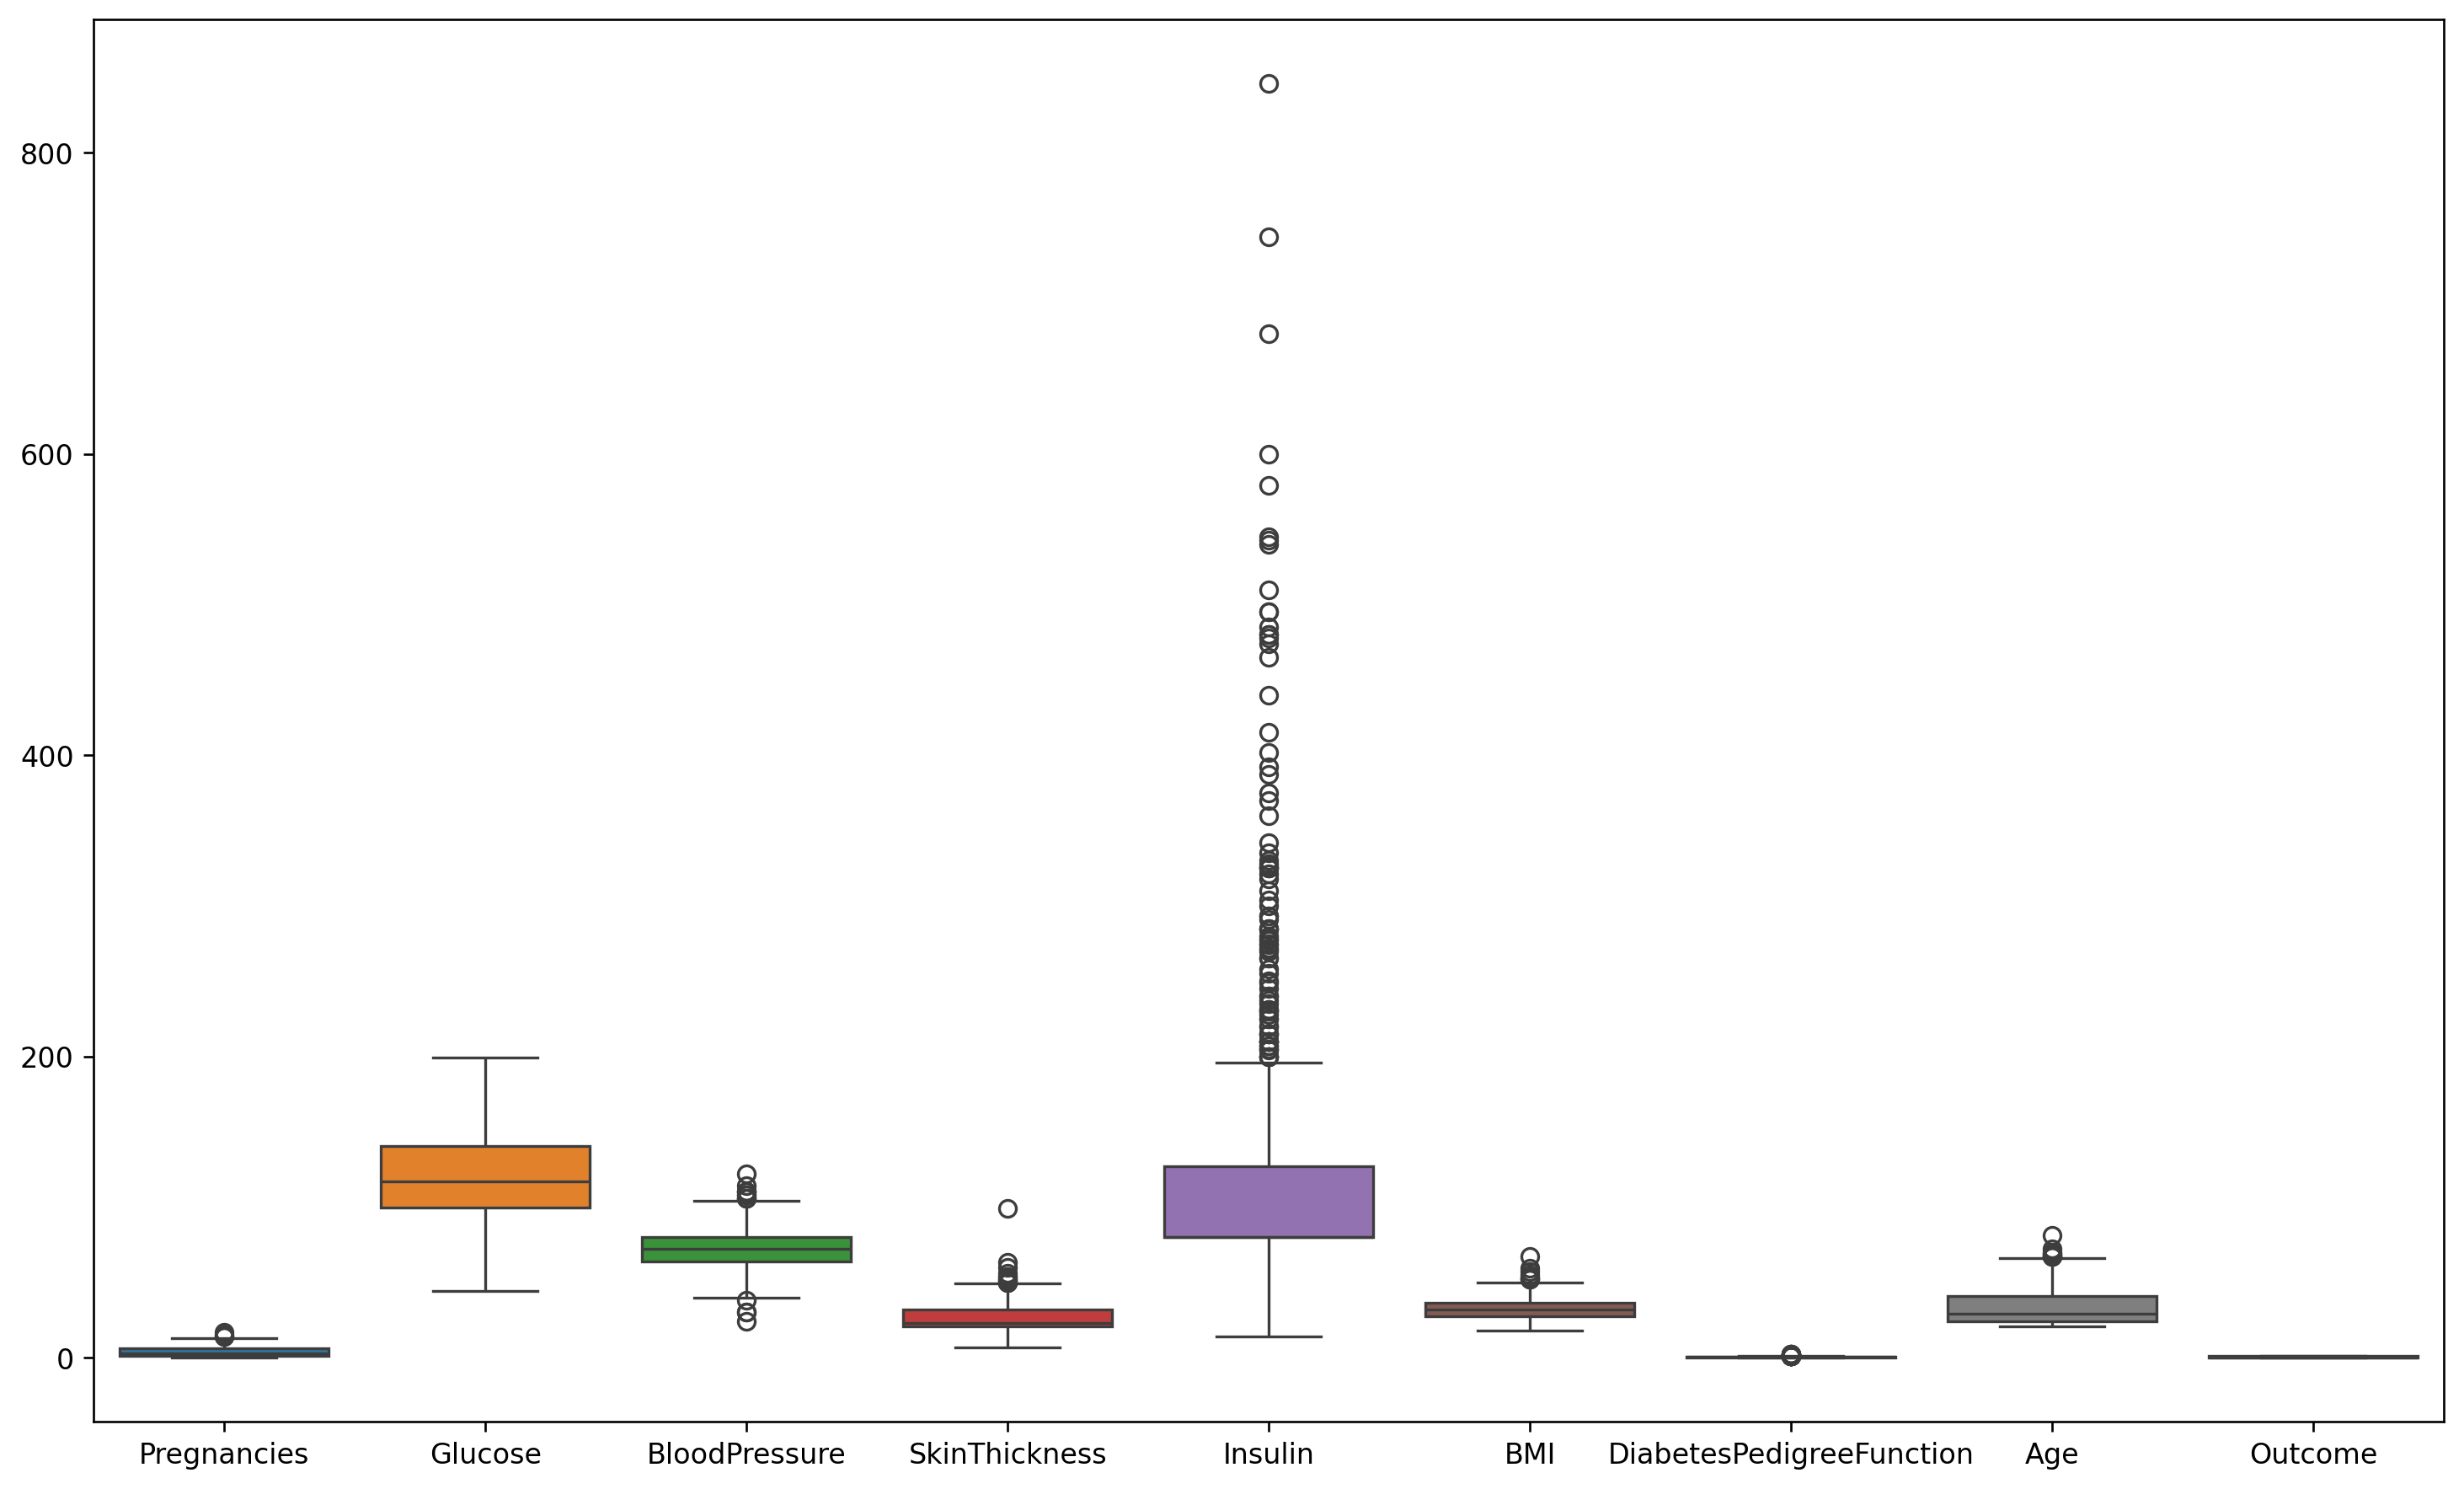

In [143]:
plt.figure(figsize=(15,9),dpi=240)
sns.boxplot(data=data)

In [144]:
data.head(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,79.799479,33.6,0.627,50,1


In [145]:
X = data.iloc[:,:-1]
y = data['Outcome']

In [146]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)
X_train.shape, X_test.shape

((576, 8), (192, 8))

In [ ]:
def std_scalar(X_train,X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    file = open(r'logistics regression\\deployment\\Model\\standardScalar.pkl','wb')
    pickle.dump(scaler,file)
    file.close()
    
    return X_train_scaled,X_test_scaled

In [148]:
X_train_scaled, X_test_scaled = std_scalar(X_train,X_test)

In [150]:
X_train_scaled,X_test_scaled

(array([[ 1.50755225, -1.09947934, -0.89942504, ..., -1.45561965,
         -0.98325882, -0.04863985],
        [-0.82986389, -0.1331471 , -1.23618124, ...,  0.09272955,
         -0.62493647, -0.88246592],
        [-1.12204091, -1.03283573,  0.61597784, ..., -0.03629955,
          0.39884168, -0.5489355 ],
        ...,
        [ 0.04666716, -0.93287033, -0.64685789, ..., -1.14021518,
         -0.96519215, -1.04923114],
        [ 2.09190629, -1.23276654,  0.11084355, ..., -0.36604058,
         -0.5075031 ,  0.11812536],
        [ 0.33884418,  0.46664532,  0.78435594, ..., -0.09470985,
          0.51627505,  2.953134  ]]),
 array([[-0.82986389,  2.56591881,  0.27922165, ...,  1.46903995,
          2.78665365, -0.96584853],
        [-0.53768687, -0.49968691,  0.11084355, ...,  0.13573925,
         -0.19434743, -0.88246592],
        [ 0.04666716, -1.53266275, -0.89942504, ...,  0.19308552,
         -0.23349189, -0.71570071],
        ...,
        [-0.82986389, -0.43304331, -1.06780314, ..., -

In [151]:
log_reg = LogisticRegression(n_jobs=-1) 

In [152]:
log_reg.fit(X_train_scaled,y_train)

LogisticRegression(n_jobs=-1)

In [154]:
parameters = {
    'penalty' : ['l1','l2'], 
    'C'       : np.logspace(-3,3,7),
    'solver'  : ['newton-cg', 'lbfgs', 'liblinear'],
}

In [160]:
logreg = LogisticRegression(n_jobs=-1)
clf = GridSearchCV(log_reg,
                   param_grid=parameters,
                   scoring='accuracy',
                   cv=5
                   )

clf.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(n_jobs=-1),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear']},
             scoring='accuracy')

In [161]:
clf.best_params_

{'C': np.float64(1.0), 'penalty': 'l1', 'solver': 'liblinear'}

In [162]:
clf.best_score_

np.float64(0.7725487256371812)

In [196]:
scaler = StandardScaler()

In [163]:
y_pred = clf.predict(X_test_scaled)

In [204]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
661,1,199.0,76.0,43.000000,79.799479,42.9,1.394,22
122,2,107.0,74.0,30.000000,100.000000,33.6,0.404,23
113,4,76.0,62.0,20.536458,79.799479,34.0,0.391,25
14,5,166.0,72.0,19.000000,175.000000,25.8,0.587,51
529,0,111.0,65.0,20.536458,79.799479,24.6,0.660,31
...,...,...,...,...,...,...,...,...
366,6,124.0,72.0,20.536458,79.799479,27.6,0.368,29
301,2,144.0,58.0,33.000000,135.000000,31.6,0.422,25
382,1,109.0,60.0,8.000000,182.000000,25.4,0.947,21
140,3,128.0,78.0,20.536458,79.799479,21.1,0.268,55


In [213]:
new_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,79.799479,33.6,0.627,50


In [214]:
# with open(r"C:\Users\Rashid\Desktop\UKDlDs\SelfCode/logistics regression/deployment/Model/standardScalar.pkl", "rb") as f:
#     scaler = pickle.load(f)

# with open(r"C:\Users\Rashid\Desktop\UKDlDs\SelfCode/logistics regression/deployment/Model/logReg.pkl", "rb") as f:
#     clf = pickle.load(f)

new_test = data.iloc[:1, :-1]
y_pred = clf.predict(scaler.transform(new_test))
print(y_pred[0])


1


In [167]:
conf_mat = confusion_matrix(y_test,y_pred)
print(conf_mat)

[[117  13]
 [ 26  36]]


In [168]:
acc_score = accuracy_score(y_test,y_pred)
print(round(acc_score,3))

0.797


In [170]:
true_positive = conf_mat[0][0]
false_positive = conf_mat[0][1]
false_negative = conf_mat[1][0]
true_negative = conf_mat[1][1]

In [173]:
Accuracy = (true_positive + true_negative) / (true_positive +false_positive + false_negative + true_negative)
print(round(Accuracy,3))

0.797


In [180]:
precision = true_positive/(true_positive+false_positive)
print(precision)

0.9


In [184]:
recall = true_positive/(true_positive+false_negative)
print(recall)

0.8181818181818182


In [ ]:
F1_Score = 2*(recall * precision) / (recall + precision)
print1(F1_Score)

0.8571428571428572


In [ ]:
file = open(r'logistics regression\\deployment\\Model\logReg.pkl','wb')
pickle.dump(log_reg,file)
file.close()